# Inspect Student vs QuSpin Test Artifacts

Run the focused tests first from the `QuantumBatteries` repository root:

```bash
conda run -n qdragon pytest -q tests/test_idden_code
```

This notebook reads the generated artifacts from `tests/test_output` and displays comparison tables and plots.

In [1]:
from pathlib import Path
from html import escape

import numpy as np
import matplotlib.pyplot as plt
from IPython.display import HTML, Markdown, display

def find_repo_root(start):
    for candidate in (start, *start.parents):
        if (candidate / 'Idden_code').exists() and (candidate / 'tests' / 'test_idden_code').exists():
            return candidate
    raise FileNotFoundError('Could not find the QuantumBatteries repository root.')

repo_root = find_repo_root(Path.cwd().resolve())
artifact_root = repo_root / 'tests' / 'test_output'
scar_artifact_root = artifact_root / 'test_quantum_scar_functions'
main_artifact_root = artifact_root / 'test_main_local'

def require_file(path):
    if not path.exists():
        raise FileNotFoundError(f'Missing artifact: {path}. Run pytest first.')
    return path

def format_value(value):
    if isinstance(value, (float, np.floating)):
        if value == 0:
            return '0'
        if abs(value) < 1e-3 or abs(value) >= 1e3:
            return f'{value:.3e}'
        return f'{value:.6g}'
    return str(value)

def display_table(rows, columns=None):
    if not rows:
        display(Markdown('_No rows to display._'))
        return
    columns = columns or list(rows[0].keys())
    header = ''.join(f'<th>{escape(column)}</th>' for column in columns)
    body_rows = []
    for row in rows:
        cells = ''.join(f'<td>{escape(format_value(row[column]))}</td>' for column in columns)
        body_rows.append(f'<tr>{cells}</tr>')
    body = ''.join(body_rows)
    display(HTML(f'<table><thead><tr>{header}</tr></thead><tbody>{body}</tbody></table>'))

display(Markdown(f'Artifact root: `{artifact_root}`'))

Artifact root: `/Users/shemian29/Library/CloudStorage/Dropbox/UIC/Research/QuantumBatteries/tests/test_output`

In [2]:
comparison_files = {
    'clean': scar_artifact_root / 'test_clean_spectrum_matches_independent_quspin' / 'clean_student_quspin_comparison.npz',
    'disordered': scar_artifact_root / 'test_disordered_spectrum_matches_independent_quspin' / 'disordered_student_quspin_comparison.npz',
}

comparisons = {label: dict(np.load(require_file(path), allow_pickle=False)) for label, path in comparison_files.items()}
summary_rows = []
for label, data in comparisons.items():
    summary_rows.append({
        'case': label,
        'levels': int(data['level_index'].size),
        'max |energy diff|': float(np.max(np.abs(data['energy_difference']))),
        'max |Z2 weight diff|': float(np.max(np.abs(data['z2_weight_difference']))),
        'sum student Z2 weight': float(np.sum(data['student_z2_weight'])),
        'sum QuSpin Z2 weight': float(np.sum(data['quspin_z2_weight'])),
    })

display_table(summary_rows)

case,levels,max |energy diff|,max |Z2 weight diff|,sum student Z2 weight,sum QuSpin Z2 weight
clean,123,8.660e-15,0.183518,1,1
disordered,123,6.217e-15,9.340e-15,1,1


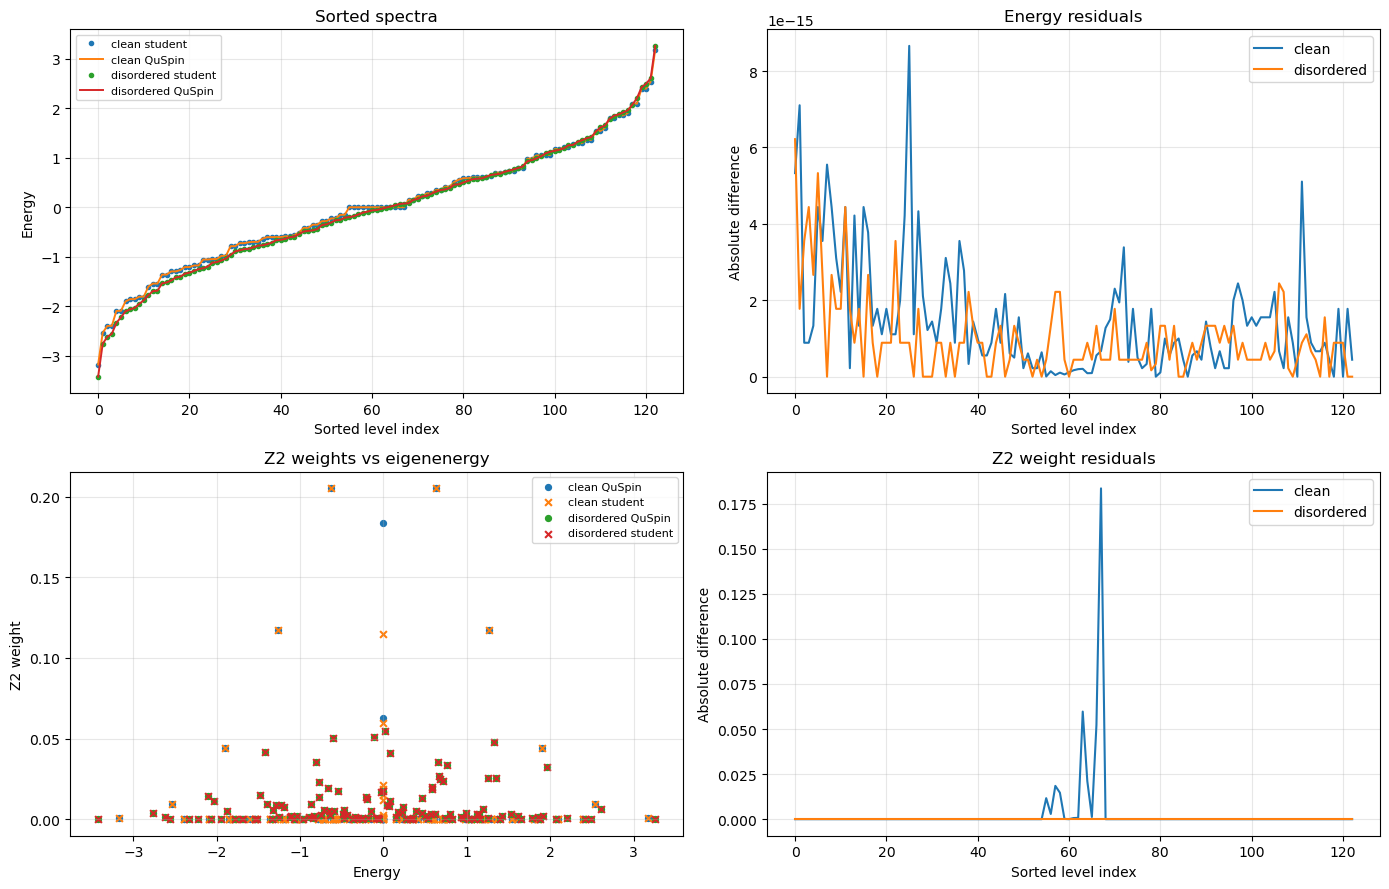

In [3]:
fig, axes = plt.subplots(2, 2, figsize=(14, 9))

for label, data in comparisons.items():
    level_index = data['level_index']
    axes[0, 0].plot(level_index, data['student_energy'], 'o', markersize=3, label=f'{label} student')
    axes[0, 0].plot(level_index, data['quspin_energy'], '-', linewidth=1.4, label=f'{label} QuSpin')
    axes[0, 1].plot(level_index, np.abs(data['energy_difference']), label=label)
    axes[1, 0].scatter(data['quspin_energy'], data['quspin_z2_weight'], s=18, label=f'{label} QuSpin')
    axes[1, 0].scatter(data['student_energy'], data['student_z2_weight'], marker='x', s=24, label=f'{label} student')
    axes[1, 1].plot(level_index, np.abs(data['z2_weight_difference']), label=label)

axes[0, 0].set_title('Sorted spectra')
axes[0, 0].set_xlabel('Sorted level index')
axes[0, 0].set_ylabel('Energy')
axes[0, 0].legend(fontsize=8)

axes[0, 1].set_title('Energy residuals')
axes[0, 1].set_xlabel('Sorted level index')
axes[0, 1].set_ylabel('Absolute difference')
axes[0, 1].legend()

axes[1, 0].set_title('Z2 weights vs eigenenergy')
axes[1, 0].set_xlabel('Energy')
axes[1, 0].set_ylabel('Z2 weight')
axes[1, 0].legend(fontsize=8)

axes[1, 1].set_title('Z2 weight residuals')
axes[1, 1].set_xlabel('Sorted level index')
axes[1, 1].set_ylabel('Absolute difference')
axes[1, 1].legend()

for ax in axes.ravel():
    ax.grid(True, alpha=0.3)

fig.tight_layout()

In [4]:
rows = []
for label, data in comparisons.items():
    order = np.argsort(-np.abs(data['energy_difference']))[:8]
    for index in order:
        rows.append({
            'case': label,
            'level': int(data['level_index'][index]),
            'student energy': float(data['student_energy'][index]),
            'QuSpin energy': float(data['quspin_energy'][index]),
            'energy diff': float(data['energy_difference'][index]),
            'student Z2': float(data['student_z2_weight'][index]),
            'QuSpin Z2': float(data['quspin_z2_weight'][index]),
            'Z2 diff': float(data['z2_weight_difference'][index]),
        })

display_table(rows)

case,level,student energy,QuSpin energy,energy diff,student Z2,QuSpin Z2,Z2 diff
clean,25,-1.04748,-1.04748,8.660e-15,3.808e-06,3.808e-06,8.022e-17
clean,1,-2.53635,-2.53635,7.105e-15,0.00968326,0.00968326,1.370e-16
clean,7,-1.85679,-1.85679,-5.551e-15,3.202e-33,4.594e-32,-4.273e-32
clean,0,-3.17778,-3.17778,5.329e-15,9.474e-04,9.474e-04,1.930e-17
clean,111,1.60254,1.60254,5.107e-15,2.719e-05,2.719e-05,-1.525e-17
clean,15,-1.36054,-1.36054,4.441e-15,6.575e-32,6.640e-35,6.568e-32
clean,8,-1.85679,-1.85679,-4.441e-15,1.828e-31,2.057e-31,-2.287e-32
clean,11,-1.60254,-1.60254,-4.441e-15,2.719e-05,2.719e-05,2.329e-17
disordered,0,-3.42285,-3.42285,-6.217e-15,2.807e-04,2.807e-04,-8.945e-18
disordered,5,-2.22209,-2.22209,5.329e-15,2.297e-04,2.297e-04,1.849e-17


artifact,time points,min Rtau_scar,max Rtau_scar,final Rtau_scar
run_one_output.npz,25,0,0.875359,0.840196


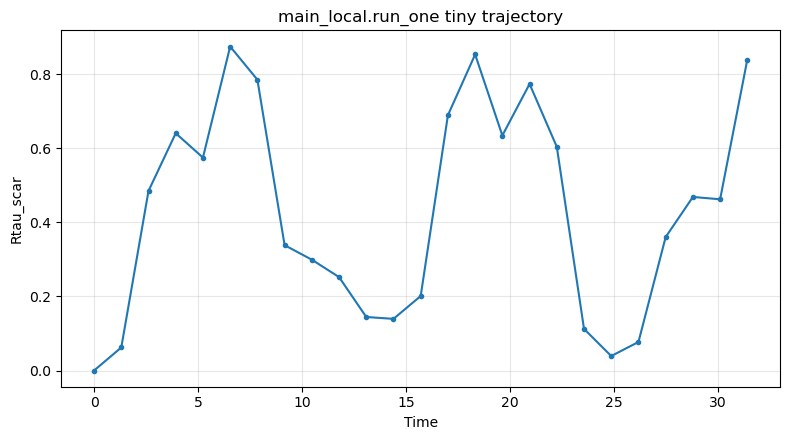

In [5]:
run_one_path = main_artifact_root / 'test_run_one_writes_expected_npz' / 'run_one_output.npz'
with np.load(require_file(run_one_path), allow_pickle=False) as run_one_data:
    tlist = run_one_data['tlist']
    rtau_scar = run_one_data['Rtau_scar']

display_table([
    {
        'artifact': run_one_path.name,
        'time points': int(tlist.size),
        'min Rtau_scar': float(np.min(rtau_scar)),
        'max Rtau_scar': float(np.max(rtau_scar)),
        'final Rtau_scar': float(rtau_scar[-1]),
    }
])

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.plot(tlist, rtau_scar, marker='o', markersize=3)
ax.set_xlabel('Time')
ax.set_ylabel('Rtau_scar')
ax.set_title('main_local.run_one tiny trajectory')
ax.grid(True, alpha=0.3)
fig.tight_layout()